In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('../data/processed/instacart.csv')
df.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,196,1,1,Soda,77.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,25133,2,1,Organic String Cheese,21.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,38928,3,1,0% Greek Strained Yogurt,120.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,26405,4,1,XL Pick-A-Size Paper Towel Rolls,54.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,39657,5,1,Milk Chocolate Almonds,45.0,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [ ]:
df.shape

(1384706, 25)

In [ ]:
df.describe()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,aisle_id,department_id,prices,Age,n_dependants,income
count,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384706e+06,1.384618e+06,1.384618e+06,1.384618e+06,1.384706e+06,1.384706e+06,1.384706e+06
mean,1.706298e+06,1.709135e+01,2.701394e+00,1.357761e+01,1.706626e+01,2.555658e+04,8.758180e+00,5.985964e-01,7.130659e+01,9.840116e+00,1.411711e+01,4.938182e+01,1.498778e+00,9.766228e+04
std,9.897342e+05,1.661400e+01,2.167637e+00,4.238461e+00,1.042639e+01,1.412097e+04,7.423973e+00,4.901825e-01,3.810535e+01,6.292848e+00,6.802253e+02,1.843685e+01,1.117567e+00,4.199139e+04
min,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.800000e+01,0.000000e+00,2.591100e+04
25%,8.433700e+05,6.000000e+00,1.000000e+00,1.000000e+01,7.000000e+00,1.338000e+04,3.000000e+00,0.000000e+00,3.100000e+01,4.000000e+00,4.300000e+00,3.300000e+01,0.000000e+00,6.485900e+04
50%,1.701880e+06,1.100000e+01,3.000000e+00,1.400000e+01,1.500000e+01,2.530000e+04,7.000000e+00,1.000000e+00,8.300000e+01,8.000000e+00,7.400000e+00,4.900000e+01,1.000000e+00,9.576500e+04
75%,2.568023e+06,2.100000e+01,5.000000e+00,1.700000e+01,3.000000e+01,3.794000e+04,1.200000e+01,1.000000e+00,1.070000e+02,1.600000e+01,1.130000e+01,6.500000e+01,2.000000e+00,1.268178e+05
max,3.421070e+06,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,4.968800e+04,8.000000e+01,1.000000e+00,1.340000e+02,2.100000e+01,9.999900e+04,8.100000e+01,3.000000e+00,5.910890e+05


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1384706 entries, 0 to 1384705
Data columns (total 25 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1384706 non-null  int64  
 1   order_number            1384706 non-null  int64  
 2   order_dow               1384706 non-null  int64  
 3   order_hour_of_day       1384706 non-null  int64  
 4   days_since_prior_order  1384706 non-null  float64
 5   product_id              1384706 non-null  int64  
 6   add_to_cart_order       1384706 non-null  int64  
 7   reordered               1384706 non-null  int64  
 8   product_name            1383473 non-null  str    
 9   aisle_id                1384618 non-null  float64
 10  department_id           1384618 non-null  float64
 11  prices                  1384618 non-null  float64
 12  department              1384618 non-null  str    
 13  aisle                   1384618 non-null  str    
 14  First Name   

In [ ]:
## Data Prep
orders_by_dow = (df[['order_id','order_dow']]
                 .drop_duplicates()
                 .groupby('order_dow')
                 .size())

type(orders_by_dow)

pandas.Series

In [ ]:
orders_by_dow

order_dow
0    27465
1    19672
2    16119
3    15687
4    15959
5    17406
6    18901
dtype: int64

In [ ]:
d = pd.DataFrame(orders_by_dow).reset_index()
d

,order_dow,0
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959
5,5,17406
6,6,18901


In [ ]:
d.columns

Index(['order_dow', 0], dtype='object')

In [ ]:
d.rename(columns={0:'number_of_orders'},inplace=True)
d

,order_dow,number_of_orders
0,0,27465
1,1,19672
2,2,16119
3,3,15687
4,4,15959
5,5,17406
6,6,18901


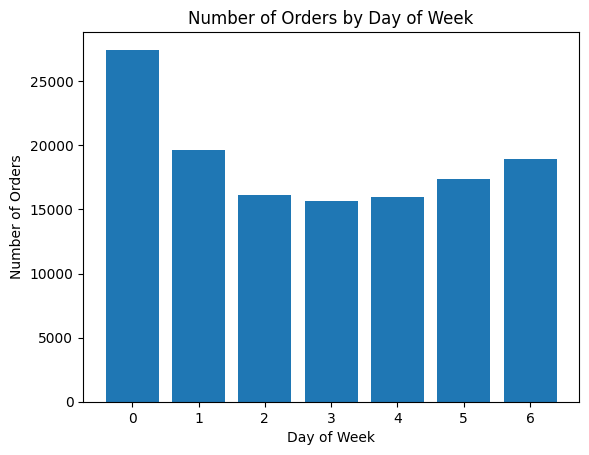

In [ ]:
plt.figure()
plt.bar(orders_by_dow.index,orders_by_dow.values)
plt.title('Number of Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.show()

In [1]:
def score_label(score):
    if score >= 90:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 50:
        return "Pass"
    else:
        return "Fail"

score_label(85)


'Good'

In [2]:
import pandas as pd

df_scores = pd.DataFrame({
    "student": ["Anna", "Ben", "Chris", "Diana", "Eva"],
    "score": [95, 78, 61, 43, 88]
})

df_scores

,student,score
0,Anna,95
1,Ben,78
2,Chris,61
3,Diana,43
4,Eva,88


In [3]:
df_scores["score_label"] = df_scores["score"].apply(score_label)
df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Good


In [4]:
df_scores["score_label"] = [score_label(i) for i in df_scores["score"]]
df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Good


In [5]:
def classify_price(price, low=5, high=15):
    if price <= low:
        return "Low-range product"
    elif price <= high:
        return "Mid-range product"
    else:
        return "High-range product"

classify_price(9)

'Mid-range product'

In [6]:
df_products_dummy = pd.DataFrame({
    "product": ["Milk", "Bread", "Juice", "Cheese", "Steak", "Apples"],
    "price": [2.5, 1.8, 6.2, 12.0, 24.5, 4.2]
})

df_products_dummy

,product,price
0,Milk,2.5
1,Bread,1.8
2,Juice,6.2
3,Cheese,12.0
4,Steak,24.5
5,Apples,4.2


In [7]:
df_products_dummy["price_range"] = df_products_dummy["price"].apply(classify_price)
df_products_dummy

,product,price,price_range
0,Milk,2.5,Low-range product
1,Bread,1.8,Low-range product
2,Juice,6.2,Mid-range product
3,Cheese,12.0,Mid-range product
4,Steak,24.5,High-range product
5,Apples,4.2,Low-range product


### Create a function called age_group_label() that groups ages into: Young for age below 30, Middle for age from 30 to 59, Senior for age 60 and above

In [9]:
df_customers_dummy = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E"],
    "age": [22, 35, 47, 63, 29],
    "income": [18000, 42000, 72000, 95000, 25000]
})

df_customers_dummy

,customer,age,income
0,A,22,18000
1,B,35,42000
2,C,47,72000
3,D,63,95000
4,E,29,25000


### Create a function called income_band() that groups income into: Low income, Middle income, High income

In [11]:
def income_band(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"

df_customers_dummy["income_group"] = df_customers_dummy["income"].apply(income_band)
df_customers_dummy

,customer,age,income,income_group
0,A,22,18000,Low income
1,B,35,42000,Middle income
2,C,47,72000,High income
3,D,63,95000,High income
4,E,29,25000,Low income


### Apply both functions to the synthetic DataFrame below.

In [12]:
df_customers_dummy = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E"],
    "age": [22, 35, 47, 63, 29],
    "income": [18000, 42000, 72000, 95000, 25000]
})

df_customers_dummy

,customer,age,income
0,A,22,18000
1,B,35,42000
2,C,47,72000
3,D,63,95000
4,E,29,25000


In [13]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt

In [14]:
df_instacart = pd.read_csv('../data/processed/instacart.csv')

In [16]:
def price_label(row):
    if row["prices"] <= 5:
        return "Low-range product"
    elif row["prices"] <= 15:
        return "Mid-range product"
    elif row["prices"] > 15:
        return "High-range product"
    else:
        return "Not enough data"


df_instacart["price_range"] = df_instacart.apply(price_label, axis=1)
df_instacart["price_range"].value_counts(dropna=False)

price_range
Mid-range product     936243
Low-range product     430870
High-range product     17505
Not enough data           88
Name: count, dtype: int64

In [17]:
df_instacart["price_range"].value_counts(dropna=False)

price_range
Mid-range product     936243
Low-range product     430870
High-range product     17505
Not enough data           88
Name: count, dtype: int64

In [18]:
df_instacart["price_range_loc"] = ""

df_instacart.loc[df_instacart["prices"] > 15, "price_range_loc"] = "High-range product"
df_instacart.loc[
    (df_instacart["prices"] > 5) & (df_instacart["prices"] <= 15),
    "price_range_loc"
] = "Mid-range product"
df_instacart.loc[df_instacart["prices"] <= 5, "price_range_loc"] = "Low-range product"

df_instacart["price_range_loc"].value_counts(dropna=False)

price_range_loc
Mid-range product     936243
Low-range product     430870
High-range product     17505
                          88
Name: count, dtype: int64

In [19]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 60:
        return "Middle"
    else:
        return "Senior"

df_instacart["age_group"] = df_instacart["Age"].apply(age_group)
df_instacart["age_group"].value_counts(dropna=False)

age_group
Middle    652827
Senior    470466
Young     261413
Name: count, dtype: int64

In [20]:
def income_group(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"

df_instacart["income_group"] = df_instacart["income"].apply(income_group)
df_instacart["income_group"].value_counts(dropna=False)

income_group
High income      975334
Middle income    398848
Low income        10524
Name: count, dtype: int64

In [21]:
def order_time_band(hour):
    if hour < 6:
        return "Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df_instacart["order_time_band"] = df_instacart["order_hour_of_day"].apply(order_time_band)
df_instacart["order_time_band"].value_counts(dropna=False)

order_time_band
Afternoon    669307
Morning      434015
Evening      254731
Night         26653
Name: count, dtype: int64

In [22]:
df_instacart["expensive_product"] = df_instacart["prices"].apply(
    lambda x: "Expensive" if x > 15 else "Not expensive"
)
df_instacart["expensive_product"].value_counts()

expensive_product
Not expensive    1367201
Expensive          17505
Name: count, dtype: int64

In [23]:
price_range_counts = df_instacart["price_range"].value_counts().sort_values()

price_range_counts

price_range
Not enough data           88
High-range product     17505
Low-range product     430870
Mid-range product     936243
Name: count, dtype: int64

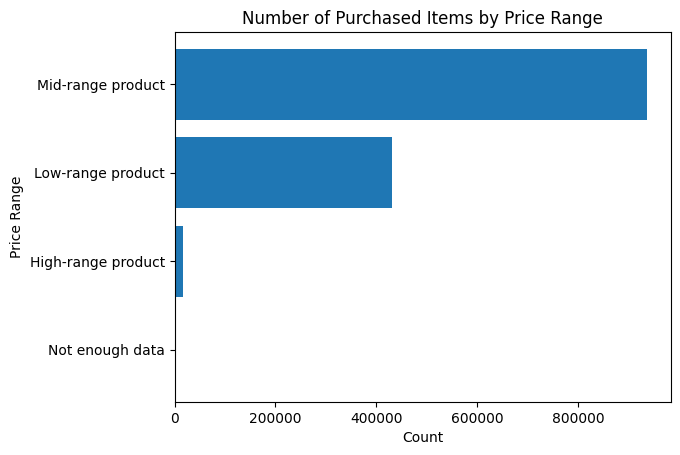

In [24]:
price_range_counts = df_instacart["price_range"].value_counts().sort_values()

plt.figure()
plt.barh(price_range_counts.index, price_range_counts.values)
plt.title("Number of Purchased Items by Price Range")
plt.xlabel("Count")
plt.ylabel("Price Range")
plt.show()

In [25]:
reorder_by_price_range = (
    df_instacart
    .groupby("price_range")["reordered"]
    .mean()
    .sort_values()
)

reorder_by_price_range

price_range
High-range product    0.579092
Low-range product     0.590833
Mid-range product     0.602527
Not enough data       0.670455
Name: reordered, dtype: float64

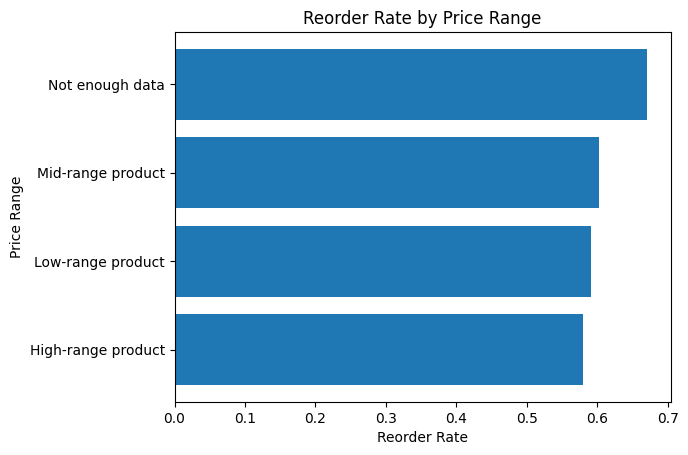

In [26]:
reorder_by_price_range = (
    df_instacart
    .groupby("price_range")["reordered"]
    .mean()
    .sort_values()
)

plt.figure()
plt.barh(reorder_by_price_range.index, reorder_by_price_range.values)
plt.title("Reorder Rate by Price Range")
plt.xlabel("Reorder Rate")
plt.ylabel("Price Range")
plt.show()

In [27]:
df_customers_unique = df_instacart[
    ["First Name", "Surname", "Age", "income", "age_group", "income_group", "region"]
].drop_duplicates()

df_customers_unique.head()

,First Name,Surname,Age,income,age_group,income_group,region
0,Linda,Nguyen,31,40423,Middle,Middle income,South
11,Norma,Chapman,68,64940,Senior,Middle income,West
42,Janet,Lester,75,115242,Senior,High income,West
51,Peter,Villegas,39,89095,Middle,High income,Northeast
60,Anna,Allison,32,88603,Middle,High income,South


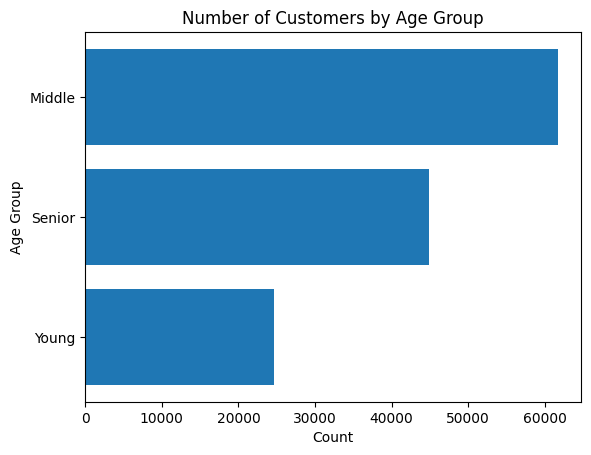

In [28]:
age_group_counts = df_customers_unique["age_group"].value_counts().sort_values()

plt.figure()
plt.barh(age_group_counts.index, age_group_counts.values)
plt.title("Number of Customers by Age Group")
plt.xlabel("Count")
plt.ylabel("Age Group")
plt.show()

In [29]:
avg_income_by_age_group = (
    df_customers_unique
    .groupby("age_group")["income"]
    .mean()
    .sort_values()
)

avg_income_by_age_group

age_group
Young      67597.200065
Middle     94492.928247
Senior    109688.877356
Name: income, dtype: float64

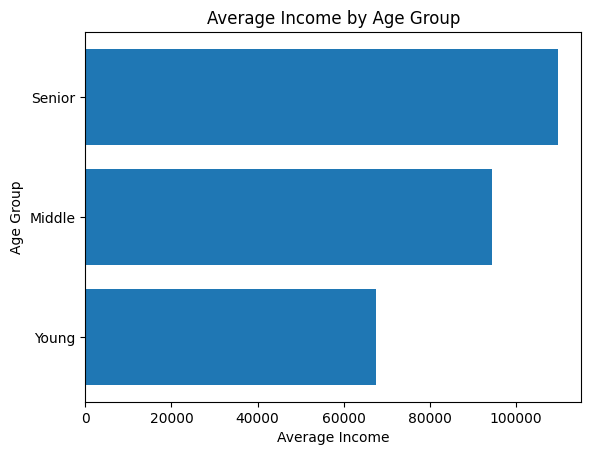

In [30]:
avg_income_by_age_group = (
    df_customers_unique
    .groupby("age_group")["income"]
    .mean()
    .sort_values()
)

plt.figure()
plt.barh(avg_income_by_age_group.index, avg_income_by_age_group.values)
plt.title("Average Income by Age Group")
plt.xlabel("Average Income")
plt.ylabel("Age Group")
plt.show()

In [31]:
orders_time_band = (
    df_instacart[["order_id", "order_time_band"]]
    .drop_duplicates()
    .groupby("order_time_band")
    .size()
    .sort_values()
)

orders_time_band

order_time_band
Night         2507
Evening      24275
Morning      41068
Afternoon    63359
dtype: int64

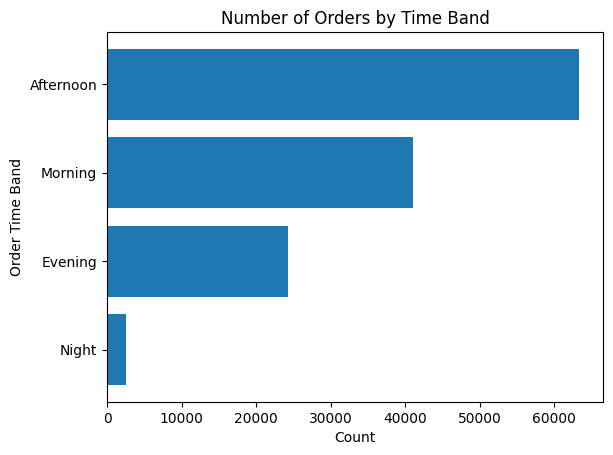

In [32]:
orders_time_band = (
    df_instacart[["order_id", "order_time_band"]]
    .drop_duplicates()
    .groupby("order_time_band")
    .size()
    .sort_values()
)

plt.figure()
plt.barh(orders_time_band.index, orders_time_band.values)
plt.title("Number of Orders by Time Band")
plt.xlabel("Count")
plt.ylabel("Order Time Band")
plt.show()